In [319]:
import numpy as np
import math
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16, 'figure.figsize': (10, 6)})
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",  
})

In [320]:
def beta_distribution(alpha,beta,theta):
    P = (math.gamma(alpha+beta)/ (math.gamma(alpha) * math.gamma(beta)))*theta**(alpha-1)*(1-theta)**(beta-1) 
    return P

def binomial_prob_distribution(n,h,theta):
    P = (math.factorial(n)/(math.factorial(n-h) * math.factorial(h))) * theta**h * (1-theta)**(n-h)
    return P

# Bayesian Inference
def bayesian_inference(prior_func, likelihood_func,theta_grid):

    prior = np.array([prior_func(t) for t in theta_grid])
    likelihood = np.array([likelihood_func(t) for t in theta_grid])

    unnorm_posterior = likelihood * prior

    evidence = np.trapz(unnorm_posterior, theta_grid)

    posterior = unnorm_posterior / evidence
    
    return posterior

In [321]:
# ---- Load data
flips = np.loadtxt("HW06_data.txt", dtype=int)
n = len(flips)
h = int(np.sum(flips))

theta_grid = np.linspace(0.001, 0.999, 1000)

# ---- Directly pass functions (no wrappers)
posterior_all = bayesian_inference(
    prior_func=lambda t: beta_distribution(1, 1, t),
    likelihood_func=lambda t: binomial_prob_distribution(n, h, t),
    theta_grid=theta_grid
)

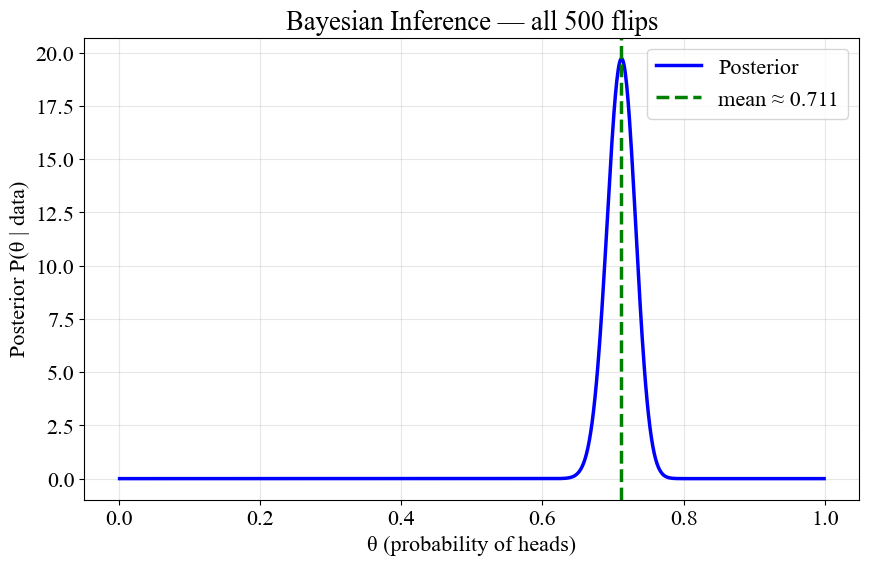

In [322]:

mean_theta_all = np.trapz(theta_grid * posterior_all, theta_grid)
plt.plot(theta_grid, posterior_all, lw=2.5, color='blue', label="Posterior")

plt.axvline(mean_theta_all, color='green', linestyle='--',lw=2.5,
            label=f"mean ≈ {mean_theta_all:.3f}")

plt.xlabel("θ (probability of heads)")
plt.ylabel("Posterior P(θ | data)")
plt.title(f"Bayesian Inference — all {len(flips)} flips")

plt.legend()
#plt.tight_layout()
plt.show()

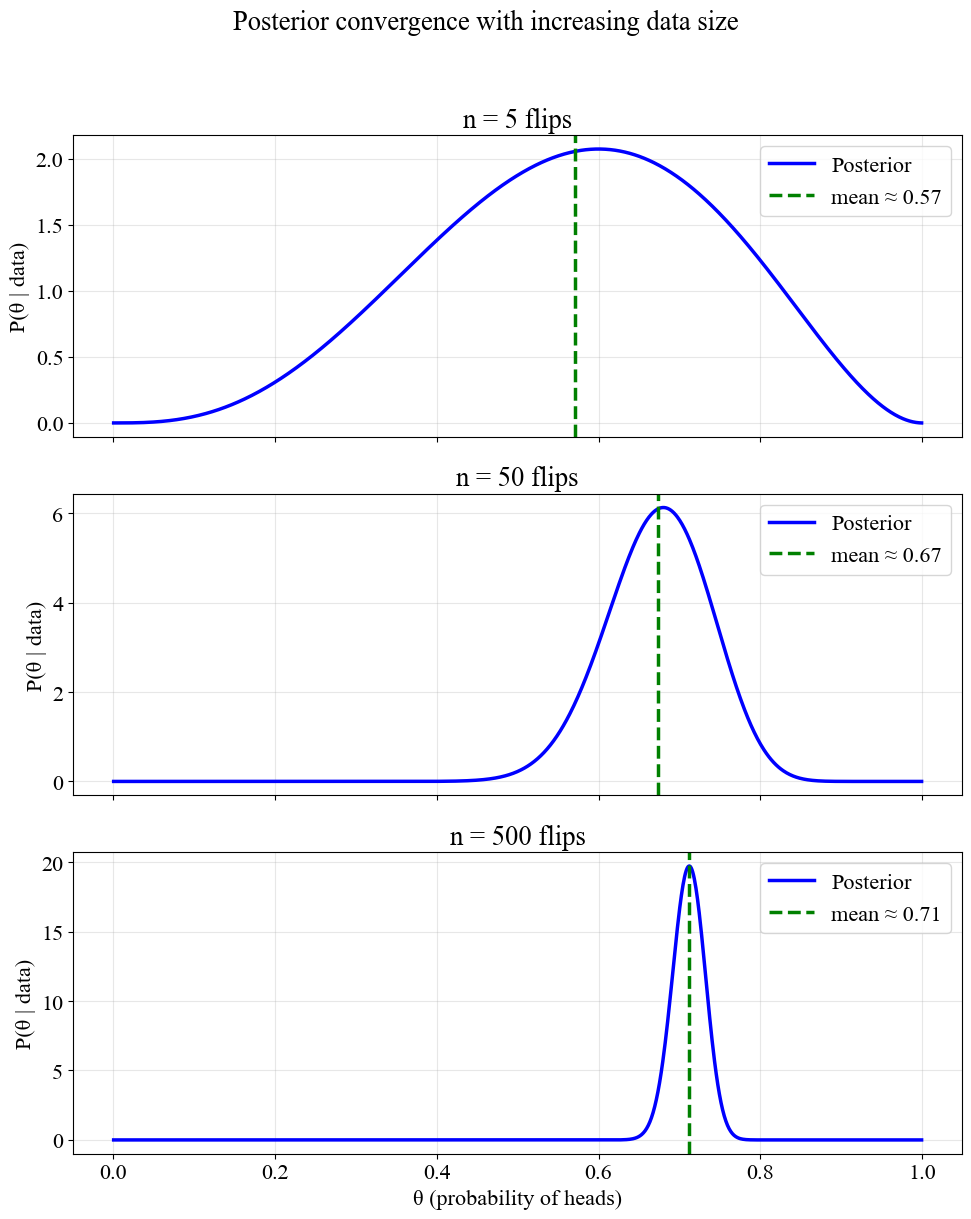

In [323]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for ax, n_flips in zip(axes, [5, 50, 500]):

    subset = flips[:n_flips]
    n = len(subset)
    h = int(np.sum(subset))

    posterior = bayesian_inference(
        prior_func=uniform_prior,
        likelihood_func=lambda t: binomial_prob_distribution(n, h, t),
        theta_grid=theta_grid
    )

    mean_theta = np.trapz(theta_grid * posterior, theta_grid)

    ax.plot(theta_grid, posterior, lw=2.5, color='blue', label="Posterior")

    ax.axvline(mean_theta, color='green', lw=2.5, linestyle='--',
               label=f"mean ≈ {mean_theta:.2f}")

    ax.set_title(f"n = {n_flips} flips")
    ax.set_ylabel("P(θ | data)")
    ax.legend()

axes[-1].set_xlabel("θ (probability of heads)")

plt.suptitle("Posterior convergence with increasing data size", y=1.02)
plt.tight_layout()
plt.show()

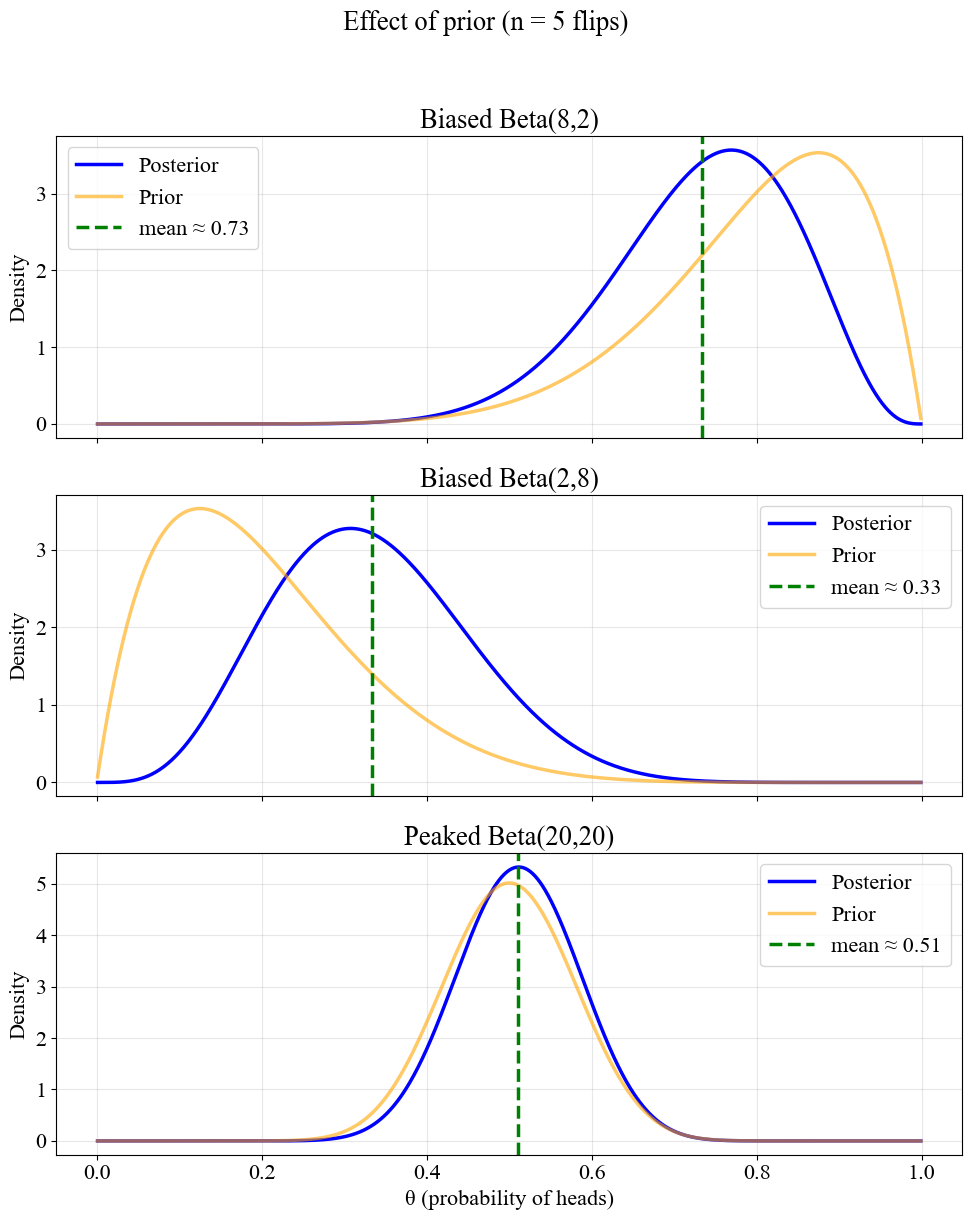

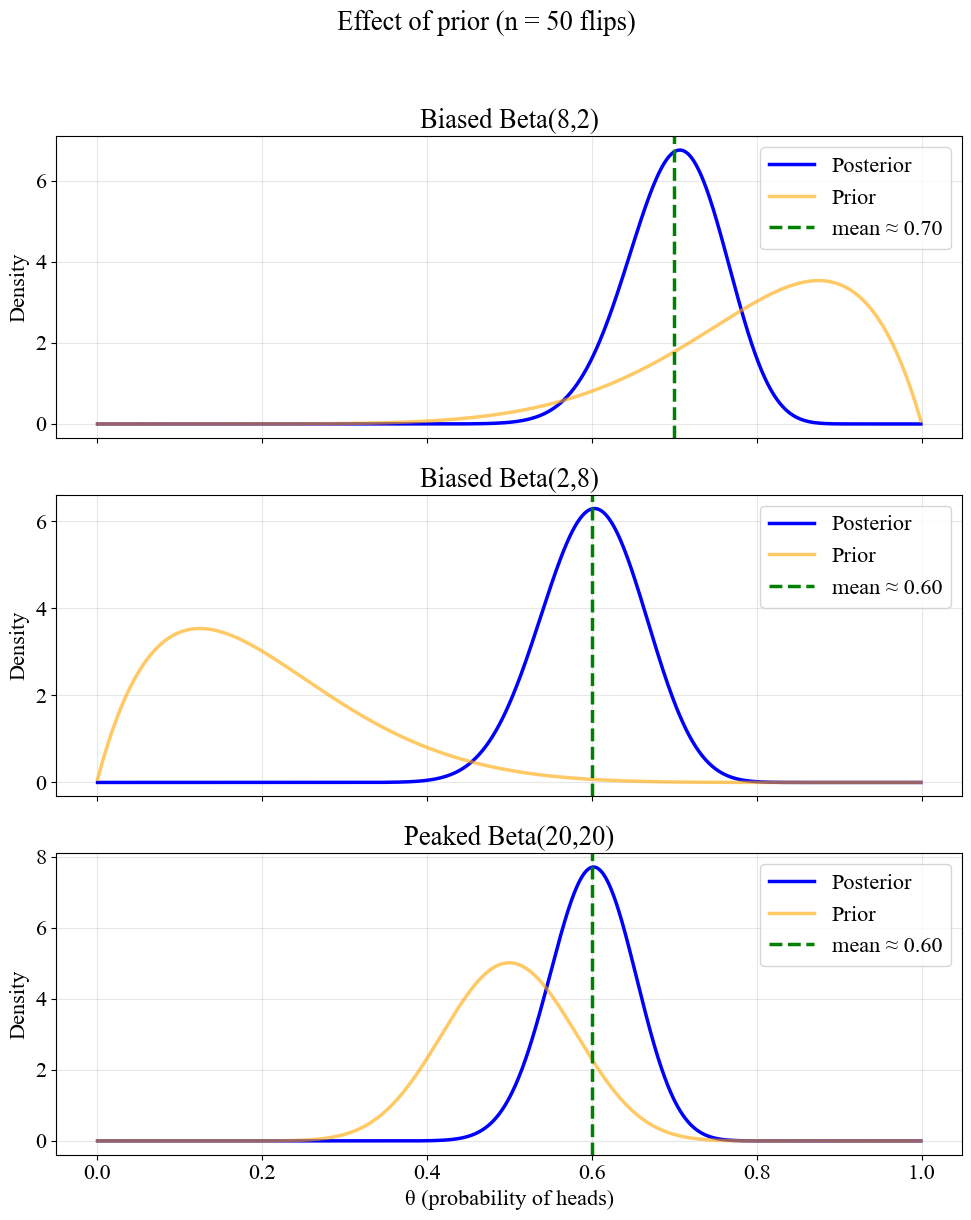

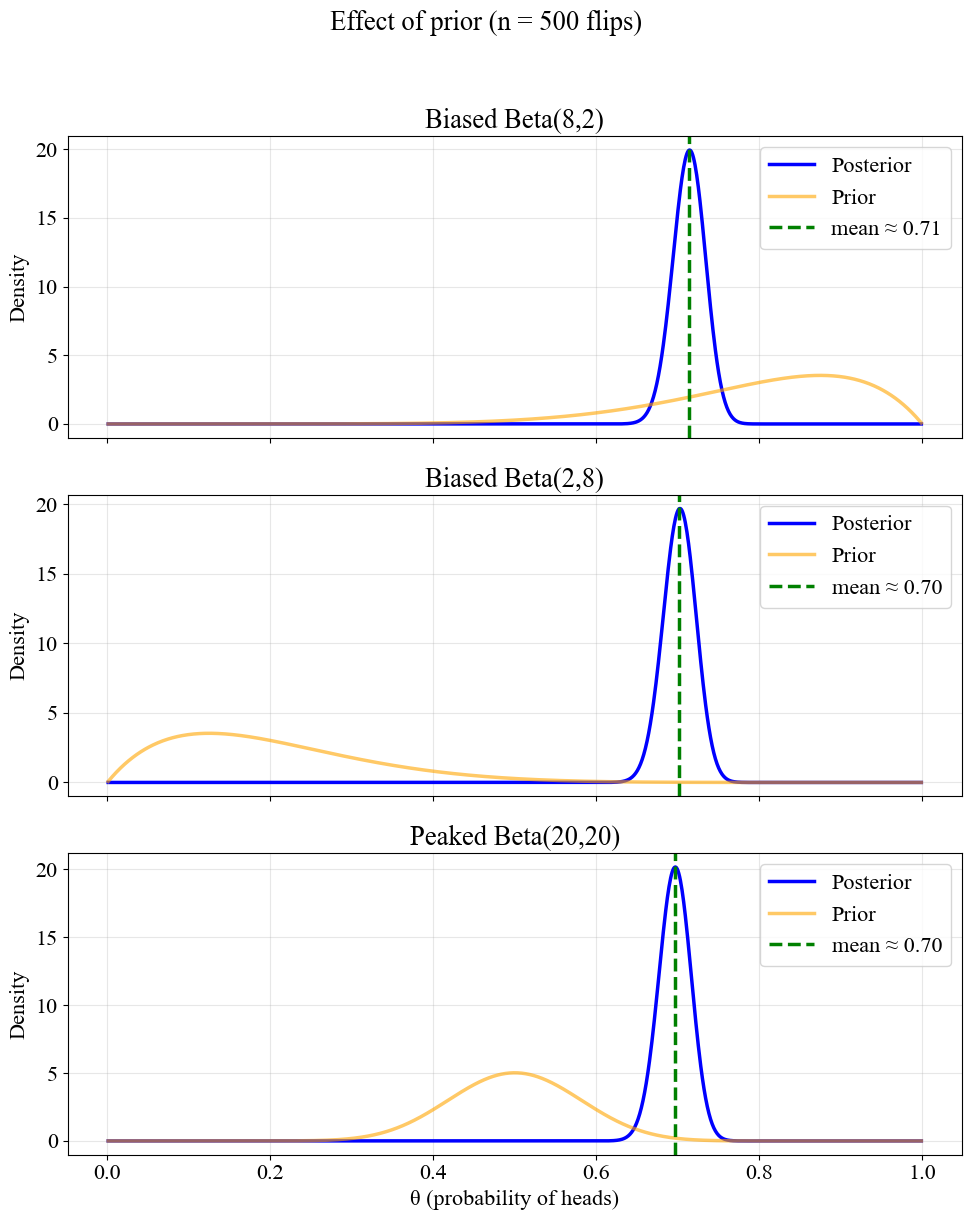

In [324]:
priors = {
    "Biased Beta(8,2)"   : lambda t: beta_distribution(8, 2, t),
    "Biased Beta(2,8)"   : lambda t: beta_distribution(2, 8, t),
    "Peaked Beta(20,20)" : lambda t: beta_distribution(20, 20, t),
}

for n_flips in [5, 50, 500]:

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    subset = flips[:n_flips]
    n = len(subset)
    h = int(np.sum(subset))

    for ax, (label, prior_fn) in zip(axes, priors.items()):

        posterior = bayesian_inference(
            prior_func=prior_fn,
            likelihood_func=lambda t: binomial_prob_distribution(n, h, t),
            theta_grid=theta_grid
        )

        mean_theta = np.trapz(theta_grid * posterior, theta_grid)

        ax.plot(theta_grid, posterior, lw=2.5, color='blue', label="Posterior")

        # prior (normalized for display)
        prior_vals = np.array([prior_fn(t) for t in theta_grid])
        prior_vals /= np.trapz(prior_vals, theta_grid)

        ax.plot(theta_grid, prior_vals, color='orange', lw=2.5,
                alpha=0.6, label="Prior")

        ax.axvline(mean_theta, color='green', lw=2.5, linestyle='--',
                   label=f"mean ≈ {mean_theta:.2f}")

        ax.set_title(label)
        ax.set_ylabel("Density")
        ax.legend()

    axes[-1].set_xlabel("θ (probability of heads)")

    plt.suptitle(f"Effect of prior (n = {n_flips} flips)", y=1.02)
    plt.tight_layout()
    plt.show()

In [325]:
def get_pi_estimate(N, alpha, beta):
    x = np.random.uniform(0, 1, N)
    y = np.random.uniform(0, 1, N)
    k = 0
    for i in range(N):
        if (x[i]**2 + y[i]**2) <= 1:
            k += 1

    theta_grid = np.linspace(0.001, 0.999, 1000)
    posterior  = bayesian_inference(
        prior_func      = lambda t: beta_distribution(alpha, beta, t),
        likelihood_func = lambda t: binomial_prob_distribution(N, k, t),
        theta_grid      = theta_grid
    )
    theta_mean  = np.trapz(theta_grid * posterior, theta_grid)
    pi_estimate = 4 * theta_mean
    return pi_estimate

In [326]:
pi = get_pi_estimate(100,1,1)
print(pi)

3.019607843137255


  N =    10 | π ≈ 2.6667 | Relative Error = 0.1512
  N =    50 | π ≈ 3.2308 | Relative Error = 0.0284
  N =   100 | π ≈ 3.3725 | Relative Error = 0.0735
  N =   500 | π ≈ 3.1873 | Relative Error = 0.0145
  N =  1000 | π ≈ 3.1896 | Relative Error = 0.0153
  N =    10 | π ≈ 1.9048 | Relative Error = 0.3937
  N =    50 | π ≈ 2.8197 | Relative Error = 0.1025
  N =   100 | π ≈ 2.8468 | Relative Error = 0.0938
  N =   500 | π ≈ 3.1311 | Relative Error = 0.0033
  N =  1000 | π ≈ 3.1375 | Relative Error = 0.0013
  N =    10 | π ≈ 3.6190 | Relative Error = 0.1520
  N =    50 | π ≈ 3.0820 | Relative Error = 0.0190
  N =   100 | π ≈ 3.1351 | Relative Error = 0.0021
  N =   500 | π ≈ 3.1311 | Relative Error = 0.0033
  N =  1000 | π ≈ 3.1573 | Relative Error = 0.0050
  N =    10 | π ≈ 3.0000 | Relative Error = 0.0451
  N =    50 | π ≈ 2.8000 | Relative Error = 0.1087
  N =   100 | π ≈ 2.9818 | Relative Error = 0.0509
  N =   500 | π ≈ 3.0824 | Relative Error = 0.0189
  N =  1000 | π ≈ 3.2079 | Rela

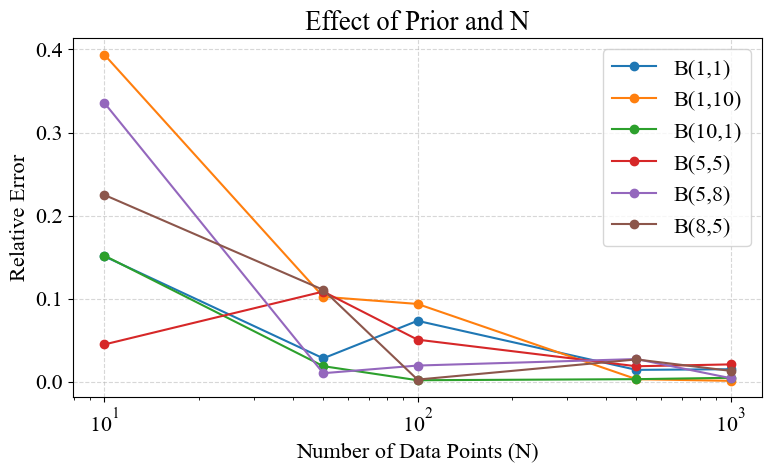

In [327]:
N_values = [10, 50, 100, 500, 1000]
priors = {
    "B(1,1)"  : (1, 1),
    "B(1,10)" : (1, 10),
    "B(10,1)" : (10, 1),
    "B(5,5)"  : (5, 5),
    "B(5,8)" : (5, 8),
    "B(8,5)" : (8, 5),
}

plt.figure(figsize=(8, 5))

for label, (a, b) in priors.items():
    errors = []
    for N in N_values:
        pi_est    = get_pi_estimate(N, a, b)
        rel_error = abs(pi_est - np.pi) / np.pi
        errors.append(rel_error)
        print(f"  N = {N:5d} | π ≈ {pi_est:.4f} | Relative Error = {rel_error:.4f}")
    plt.plot(N_values, errors, 'o-', label=label)

plt.xscale('log')
#plt.yscale('log')
plt.xlabel("Number of Data Points (N)")
plt.ylabel("Relative Error")
plt.title("Effect of Prior and N")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()